[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter0_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 0: Introduction

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Reproduces every chart of the Chapter 0 lecture from the course data (daily data from EODHD, to 18 September 2026).
- Sections: five markets since 2015; risk and return; drawdowns; the VIX; the BET index; daily returns and heavy tails; Bitcoin volatility per year (the AI-discovery mini-case).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_0'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

In [5]:
# the palette names as attributes of the style namespace `st` (st.MainBlue, st.Teal, ...)
for _c in ('MainBlue', 'IDAred', 'Forest', 'Amber', 'Purple', 'Orange', 'Teal', 'Crimson', 'DarkText'):
    setattr(st, _c, globals()[_c])

## Chapter constants and helpers

- Annualisation uses the actual number of observations per year of each series (about 252 for exchanges, 365 for Bitcoin).

In [6]:
MARKETS_CH0 = ['sp500', 'dax', 'bettr', 'btc', 'gold']
START_CH0 = '2015-01-01'
START_LONG = '2000-01-01'
RISK_RETURN = ['sp500', 'ndx', 'dax', 'stoxx50', 'nikkei', 'bettr', 'wig20', 'gold', 'tlt', 'btc', 'eth']
COLOURS_RR = {'sp500': '#1A3A6E', 'ndx': '#17A2B8', 'dax': '#2E7D32', 'stoxx50': '#8E44AD', 'nikkei': '#DC3545', 'bettr': '#E67E22', 'wig20': '#CD0000', 'gold': '#B5853F', 'tlt': '#2E7D32', 'btc': '#B5853F', 'eth': '#8E44AD'}
MARKERS_RR = {'tlt': 's', 'btc': 's', 'eth': 's', 'gold': 'D'}
OFFSETS_RR = {'sp500': (-8, 8), 'gold': (-38, -14), 'dax': (6, -12), 'stoxx50': (-30, -16), 'wig20': (6, -10), 'nikkei': (6, 2), 'ndx': (6, 4), 'bettr': (6, 4), 'tlt': (6, 4), 'btc': (6, 4), 'eth': (-62, -4)}


def market_table(names=MARKETS_CH0, start=START_CH0):
    """Annualised mean log return and volatility (%), with the actual observation frequency of each series."""
    rows = {}
    for k in names:
        r = log_returns(k, start)
        ppy = periods_per_year(r)
        p = load_close(k, start)
        rows[LABELS[k]] = {'first': r.index[0].date(), 'last': r.index[-1].date(), 'n': len(r),
                           'obs_per_year': ppy, 'ann_return': r.mean() * ppy, 'ann_vol': r.std() * np.sqrt(ppy),
                           'multiple': p.iloc[-1] / p.iloc[0]}
    return pd.DataFrame(rows).T


def drawdown(p):
    """Drawdown DD_t = P_t / max_{s<=t} P_s - 1 (in %)."""
    return 100 * (p / p.cummax() - 1)


def annual_vol(name, start=START_CH0):
    """Annualised volatility (%) of daily log returns in each calendar year: daily standard deviation times the
    square root of the series' observations per year (about 252 for exchanges, 365 for Bitcoin)."""
    r = log_returns(name, start)
    ppy = periods_per_year(r)
    return r.groupby(r.index.year).std() * np.sqrt(ppy)

## 1. Five markets since 2015

- Growth of 100 invested in January 2015, log scale: equal vertical distances are equal percentage changes.
- Table: final over initial price, annualised mean log return and annualised volatility (%).

In [7]:
def fig_markets(names=MARKETS_CH0, start=START_CH0, save=True):
    """Growth of 100 invested at the first common date, log scale, legend below the plot."""
    px = pd.concat([load_close(k, start) for k in names], axis=1).ffill().dropna()
    idx = 100 * px / px.iloc[0]
    fig, ax = plt.subplots(figsize=(10, 4.4))
    for k in names:
        ax.plot(idx.index, idx[k], color=st.COL[k], lw=1.3, label=LABELS[k])
    ax.set_yscale('log')
    ax.set_ylabel('Value of 100 invested (log scale)')
    st.legend_outside_bottom(ax, ncol=len(names), y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch0_markets')
    return idx

In [8]:
tab = market_table()
tab.round(2)

,first,last,n,obs_per_year,ann_return,ann_vol,multiple
S&P 500,2015-01-05,2026-09-18,2943,251.504621,11.220193,17.689835,3.717083
DAX,2015-01-05,2026-09-18,2972,253.98292,8.137264,19.071522,2.591373
BET-TR,2015-01-06,2026-09-18,2925,250.024865,20.005394,15.473223,10.385372
Bitcoin,2015-01-02,2026-09-18,4278,365.335399,47.403092,66.680182,257.443819
Gold (XAU/USD),2015-01-02,2026-09-18,3049,260.380465,11.186098,16.325842,3.705686


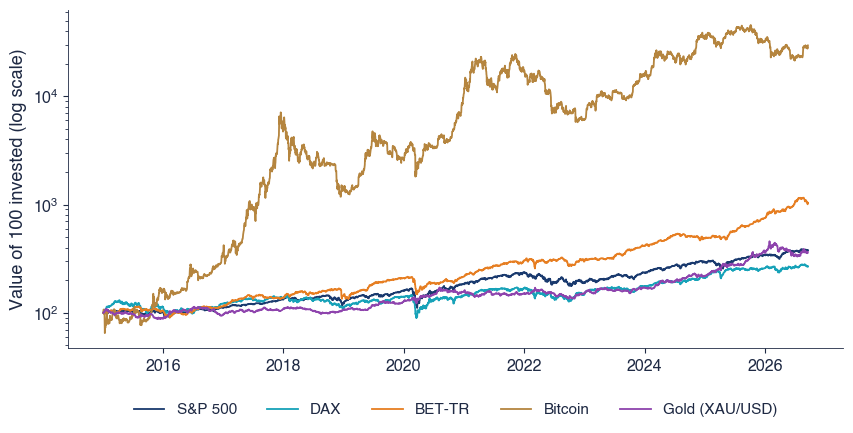

In [9]:
fig_markets(save=False)
plt.show()

## 2. Risk and return, 2015–2026

- Each point is one market: annualised volatility (log scale) against annualised mean log return.
- One sample of eleven years: a different window gives a different ranking.

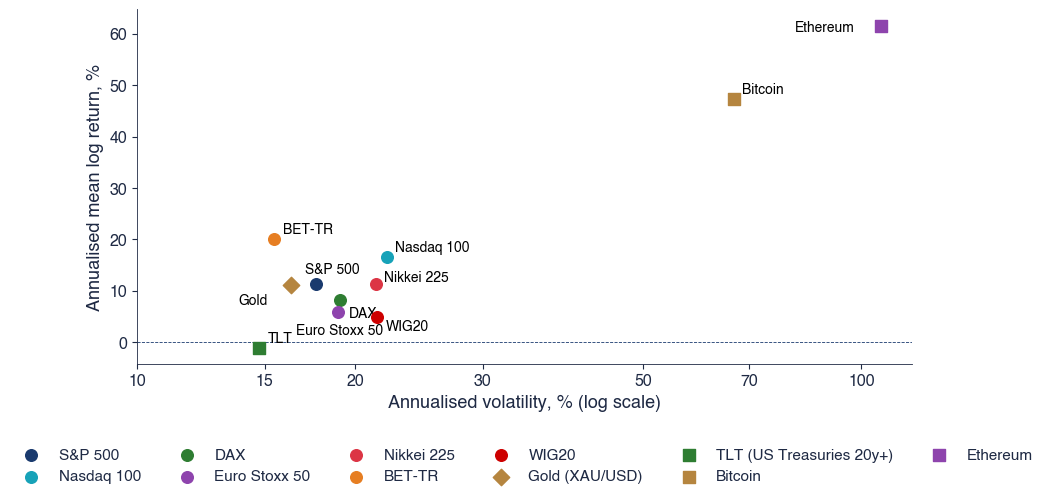

,ann_return,ann_vol
S&P 500,11.220193,17.689835
Nasdaq 100,16.638844,22.108646
DAX,8.137264,19.071522
Euro Stoxx 50,5.86525,18.925093
Nikkei 225,11.263583,21.386732
BET-TR,20.005394,15.473223
WIG20,4.952164,21.476029
Gold (XAU/USD),11.186098,16.325842
TLT (US Treasuries 20y+),-1.055115,14.750025
Bitcoin,47.403092,66.680182


In [10]:
def fig_risk_return(names=RISK_RETURN, start=START_CH0, save=True):
    """Annualised volatility (x) against annualised mean log return (y), each series on its own calendar."""
    tab = market_table(names, start)
    fig, ax = plt.subplots(figsize=(10, 4.6))
    for k in names:
        row = tab.loc[LABELS[k]]
        ax.scatter(row['ann_vol'], row['ann_return'], s=70, color=COLOURS_RR[k], marker=MARKERS_RR.get(k, 'o'),
                   label=LABELS[k], zorder=3)
        ax.annotate(LABELS[k].split(' (')[0], (row['ann_vol'], row['ann_return']), xytext=OFFSETS_RR.get(k, (6, 4)),
                    textcoords='offset points', fontsize=10, color='black', ha='left')
    ax.axhline(0, color=st.MainBlue, lw=0.6, ls='--')
    ax.set_xscale('log')
    ax.set_xticks([10, 15, 20, 30, 50, 70, 100])
    ax.set_xticklabels(['10', '15', '20', '30', '50', '70', '100'])
    ax.minorticks_off()
    ax.set_xlabel('Annualised volatility, % (log scale)')
    ax.set_ylabel('Annualised mean log return, %')
    st.legend_outside_bottom(ax, ncol=6, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch0_risk_return')
    return tab


rr = fig_risk_return(save=False)
plt.show()
rr[['ann_return', 'ann_vol']].round(1)

## 3. Crises and drawdowns, 2000–2026

- Drawdown $DD_t = P_t / \max_{s \le t} P_s - 1$: the loss from the highest previous price.

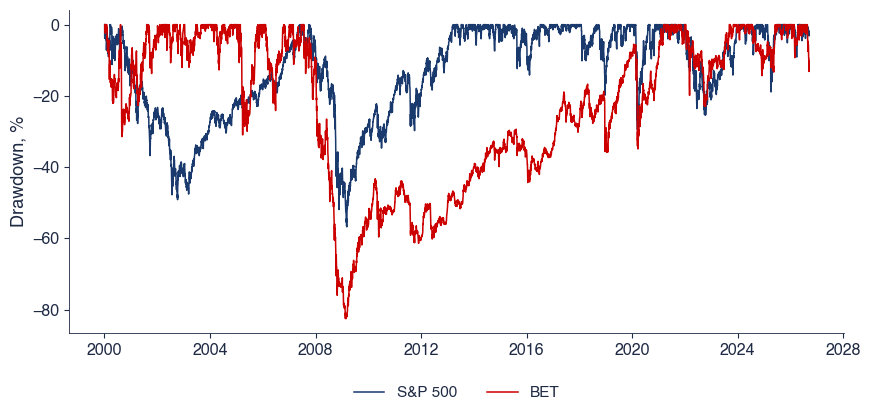

sp500 maximum drawdown -56.8 % on 2009-03-09
bet maximum drawdown -82.5 % on 2009-02-25


In [11]:
def fig_drawdowns(start=START_LONG, save=True):
    """Drawdown of the S&P 500 and of the BET index (closing prices, each on its own calendar)."""
    out = {}
    fig, ax = plt.subplots(figsize=(10, 4.2))
    for k in ('sp500', 'bet'):
        dd = drawdown(load_close(k, start))
        ax.plot(dd.index, dd, color=st.COL[k], lw=1.1, label=LABELS[k])
        out[k] = dd
    ax.set_ylabel('Drawdown, %')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch0_drawdowns')
    return out


dd = fig_drawdowns(save=False)
plt.show()
for k, d in dd.items():
    print(k, 'maximum drawdown', round(d.min(), 1), '% on', d.idxmin().date())

## 4. The VIX, 2000–2026

- The VIX is the volatility of the S&P 500 over the next 30 days expected by option traders, in % a year.

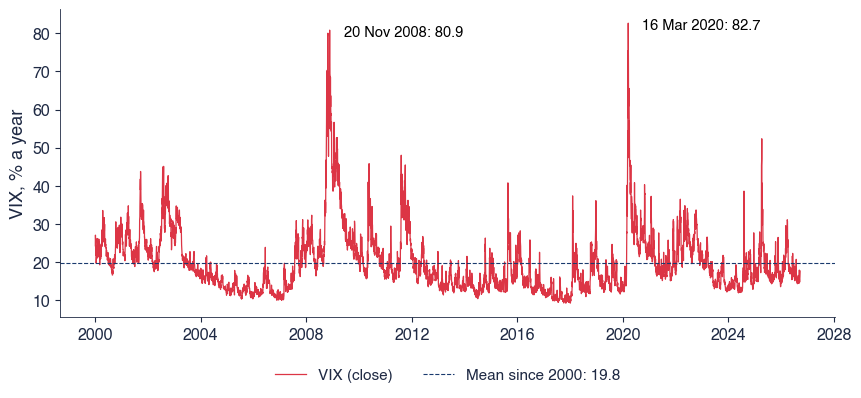

mean 19.8 median 17.8


In [12]:
def fig_vix(start=START_LONG, save=True):
    """The VIX index (implied volatility of the S&P 500, % a year), with the two highest closes marked."""
    v = load_close('vix', start)
    top = [v.loc[:'2012'].idxmax(), v.loc['2013':].idxmax()]
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(v.index, v, color=st.COL['vix'], lw=0.9, label='VIX (close)')
    ax.axhline(v.mean(), color=st.MainBlue, lw=0.8, ls='--', label=f'Mean since 2000: {v.mean():.1f}')
    for d in top:
        ax.annotate(f'{d:%d %b %Y}: {v[d]:.1f}', (d, v[d]), xytext=(10, -4), textcoords='offset points',
                    fontsize=10.5, color='black')
    ax.set_ylabel('VIX, % a year')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch0_vix')
    return v, top


v, top = fig_vix(save=False)
plt.show()
print('mean', round(v.mean(), 1), 'median', round(v.median(), 1))

## 5. The BET index since 1997

- Launched on 19 September 1997 at 1000 points; log scale; without dividends.

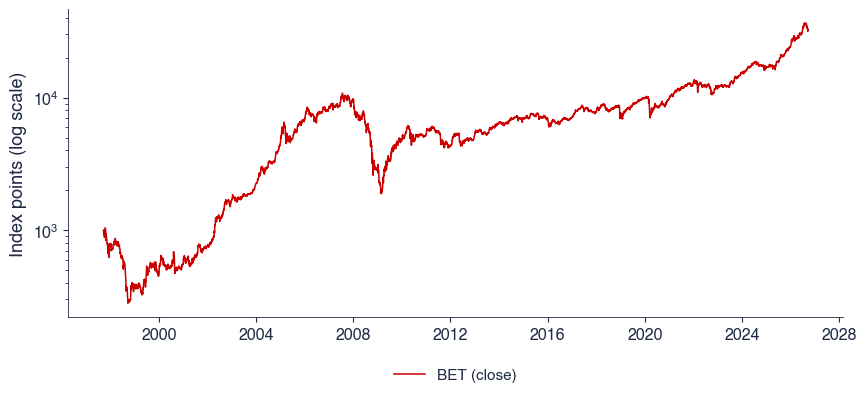

1997-09-19 1000.0 2026-09-18 32757.81


In [13]:
def fig_bet_history(save=True):
    """The BET index since its launch on 19 September 1997 (base 1000), log scale."""
    p = load_close('bet', '1997-01-01')
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(p.index, p, color=st.COL['bet'], lw=1.1, label='BET (close)')
    ax.set_yscale('log')
    ax.set_ylabel('Index points (log scale)')
    st.legend_outside_bottom(ax, ncol=1, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch0_bet_history')
    return p


p = fig_bet_history(save=False)
plt.show()
print(p.index[0].date(), p.iloc[0], p.index[-1].date(), round(p.iloc[-1], 2))

## 6. Daily returns and heavy tails

- Daily log returns of the S&P 500 since 2000: calm and turbulent periods alternate (volatility clustering).
- Histogram against the Normal density with the same mean and variance; kurtosis of the Normal distribution: 3.

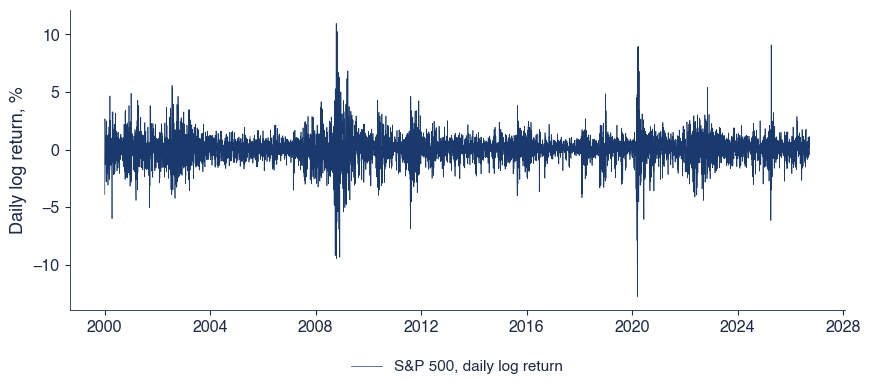

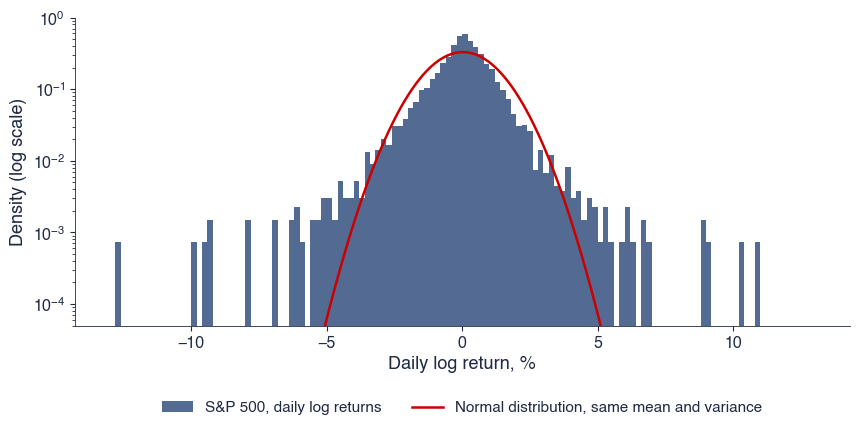

In [14]:
def fig_returns(start=START_LONG, save=True):
    """Daily log returns of the S&P 500 (%): calm and turbulent periods alternate."""
    r = log_returns('sp500', start)
    fig, ax = plt.subplots(figsize=(10, 3.9))
    ax.plot(r.index, r, color=st.MainBlue, lw=0.5, label='S&P 500, daily log return')
    ax.set_ylabel('Daily log return, %')
    st.legend_outside_bottom(ax, ncol=1, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch0_returns')
    return r


def fig_histogram(start=START_LONG, save=True):
    """Histogram of S&P 500 daily log returns against the Normal density with the same mean and variance."""
    r = log_returns('sp500', start)
    x = np.linspace(-13, 13, 600)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.hist(r, bins=np.arange(-13, 13.01, 0.2), density=True, color=st.MainBlue, alpha=0.75, label='S&P 500, daily log returns')
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), color=st.IDAred, lw=1.8,
            label='Normal distribution, same mean and variance')
    ax.set_yscale('log')
    ax.set_ylim(5e-5, 1)
    ax.set_xlabel('Daily log return, %')
    ax.set_ylabel('Density (log scale)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch0_histogram')
    return r


r = fig_returns(save=False)
plt.show()
fig_histogram(save=False)
plt.show()

In [15]:
z = (r - r.mean()) / r.std()
print('observations:', len(r))
print('kurtosis:', round(stats.kurtosis(r, fisher=False), 2))
print('days beyond 4 standard deviations:', int((z.abs() > 4).sum()),
      '; expected under the Normal distribution:', round(len(r) * 2 * stats.norm.sf(4), 2))

observations: 6714
kurtosis: 13.67
days beyond 4 standard deviations: 46 ; expected under the Normal distribution: 0.43


## 7. AI for scientific discovery: has Bitcoin become less volatile?

- Annualised volatility per calendar year: Bitcoin with 365 days, the S&P 500 with its own frequency.
- Before drawing a conclusion: fix the break date (January 2024, the spot ETFs) in advance, compare with the S&P 500, and remember that one year is a short sample.

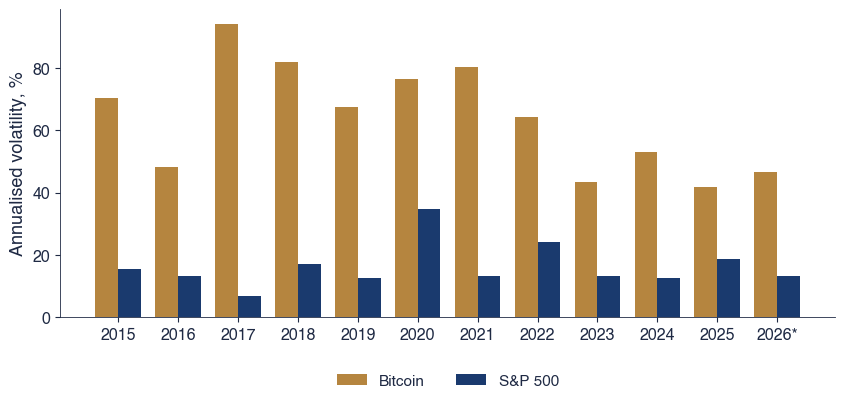

,btc,sp500,ratio
date,,,
2015,70.31,15.52,4.53
2016,48.26,13.10,3.68
2017,94.23,6.69,14.08
2018,81.94,17.08,4.80
2019,67.53,12.48,5.41
2020,76.59,34.65,2.21
2021,80.36,13.09,6.14
2022,64.21,24.17,2.66
2023,43.30,13.07,3.31


In [16]:
def fig_btc_vol(save=True):
    """Annualised volatility per calendar year: Bitcoin (365 days a year) against the S&P 500 (about 252)."""
    b, s = annual_vol('btc'), annual_vol('sp500')
    years = b.index
    fig, ax = plt.subplots(figsize=(10, 4.0))
    w = 0.38
    ax.bar(years - w / 2, b, width=w, color=st.COL['btc'], label='Bitcoin')
    ax.bar(years + w / 2, s.reindex(years), width=w, color=st.COL['sp500'], label='S&P 500')
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) if y < 2026 else '2026*' for y in years])
    ax.set_ylabel('Annualised volatility, %')
    st.legend_outside_bottom(ax, ncol=2, y=-0.14)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch0_btc_vol')
    return pd.DataFrame({'btc': b, 'sp500': s})


bv = fig_btc_vol(save=False)
plt.show()
bv['ratio'] = bv['btc'] / bv['sp500']
bv.round(2)

In [17]:
print('Bitcoin, mean annual volatility 2015-2023:', round(bv.loc[2015:2023, 'btc'].mean(), 1))
print('Bitcoin, mean annual volatility 2024-2026:', round(bv.loc[2024:2026, 'btc'].mean(), 1))

Bitcoin, mean annual volatility 2015-2023: 69.6
Bitcoin, mean annual volatility 2024-2026: 47.3
